Ce fichier est un exemple d'affichage de données spatiales sur une carte avec cartiflette + geopands

In [13]:
# exemple d'utilisation de load_fonds_carte qui récupère les bordures des départements et des communes d'IDF
import geopandas as gpd
import matplotlib.pyplot as plt
from download_fond_carte import load_fonds_carte

coms, deps = load_fonds_carte(crs=4326, force_download=False)

# Listes filtrées de la "petite couronne"
PETITE_COURONNE = [75, 92, 93, 94]
coms_pc = coms[coms["INSEE_DEP"].astype(int).isin(PETITE_COURONNE)].copy()
deps_pc = deps[deps["INSEE_DEP"].astype(int).isin(PETITE_COURONNE)].copy()

Téléchargement des bordures de communes / départements mis en cache


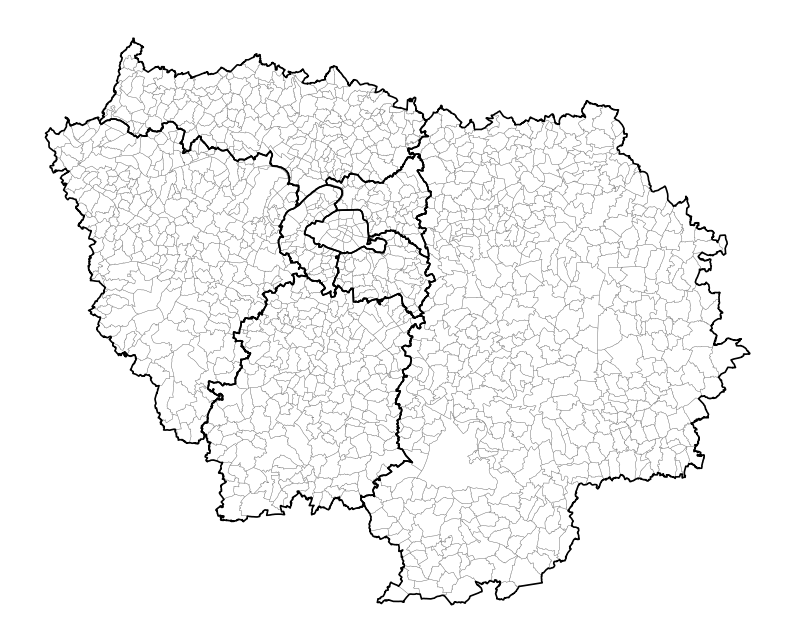

In [ ]:
# Exemple d'affichage d'un fond de carte
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
deps.boundary.plot(ax=ax, linewidth=1.2, edgecolor="black", zorder=2)
coms.boundary.plot(ax=ax, linewidth=0.25, edgecolor="gray", zorder=1, alpha=0.9)


ax.set_axis_off()

In [25]:
# Exemple d'utilisation avec une autre base de donnée
# On affiche le nombre d'arret de bus / gare au km²

# récupération des données complémentaires
url_idfm = 'https://transport.data.gouv.fr/resources/conversions/80921/GeoJSON'
stations = gpd.read_file(url_idfm)

# spatial join
stations_info = gpd.sjoin(stations, coms, how="left", predicate="within")

# groupe par commune
stations_stats = stations_info.groupby("INSEE_COG", as_index=False).agg(
    nb_stations=("id", "count"),
)

# On fusionne avec la géométrie
coms_pc_stats = coms_pc.merge(stations_stats, on="INSEE_COG", how="left")

# calculer la surface en km² en projetant en Lambert-93 (EPSG:2154), puis densité = nb_stations / km²
gdf_proj = coms_pc_stats.to_crs(epsg=2154)
coms_pc_stats["area_km2"] = gdf_proj.geometry.area / 1e6
coms_pc_stats["nb_stations"] = coms_pc_stats["nb_stations"].fillna(0)
coms_pc_stats["density_per_km2"] = coms_pc_stats["nb_stations"] / coms_pc_stats["area_km2"]

# afficher la carte de densité
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

coms_pc_stats.plot(
    column="density_per_km2",
    ax=ax,
    legend=True,
    cmap="Blues",
    edgecolor="gray",
    linewidth=0.25
)
deps_pc.boundary.plot(ax=ax, linewidth=1.2, edgecolor="black", zorder=2)

ax.set_axis_off()

URLError: <urlopen error [Errno -3] Temporary failure in name resolution>